In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import xgcm
import matplotlib.pyplot as plt
import xbudget

from load_example_ecco_grid import * 
from eccov4r4_budget_diagnostics import * 
from xbudget.llc90 import * 
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xarray: 2026.4.0
xgcm: 0.1.dev617+gb29dfdecb


In [3]:
def calc_uv_bolus(ds, grid, allow_rechunk=True):
    psix = ds["GM_PsiX"].where(np.isfinite(ds["GM_PsiX"]), 0.0)
    psiy = ds["GM_PsiY"].where(np.isfinite(ds["GM_PsiY"]), 0.0)

    psix_u = psix * ds["dyG"]
    psiy_v = psiy * ds["dxG"]

    UBOL_TRSP = grid.diff(psix_u.chunk({"k_l": -1}), "Z", boundary="fill")
    VBOL_TRSP = grid.diff(psiy_v.chunk({"k_l": -1}), "Z", boundary="fill")

    psi_diff = diff_2d_flux_llc90(
        grid,
        psix_u.unify_chunks(),
        psiy_v.unify_chunks(),
        allow_rechunk=allow_rechunk,
    )

    WBOL_TRSP = psi_diff["X"] + psi_diff["Y"]

    UBOL_TRSP = UBOL_TRSP.where(ds["maskW"]).fillna(0.0)
    VBOL_TRSP = VBOL_TRSP.where(ds["maskS"]).fillna(0.0)
    WBOL_TRSP = WBOL_TRSP.fillna(0.0)

    UVELSTAR = UBOL_TRSP / (ds["drF"] * ds["dyG"])
    VVELSTAR = VBOL_TRSP / (ds["drF"] * ds["dxG"])
    WVELSTAR = WBOL_TRSP / ds["rA"]

    return xr.Dataset(
        {
            "UVELSTAR": UVELSTAR.rename("UVELSTAR"),
            "VVELSTAR": VVELSTAR.rename("VVELSTAR"),
            "WVELSTAR": WVELSTAR.rename("WVELSTAR"),
        }
    )

In [4]:
transport_ds_path = "../../example-ECCOV4r4-budget-terms/data/ECCO_transport_terms.zarr"

ds = xr.open_mfdataset(transport_ds_path, parallel = True, engine = "zarr").fillna(0.0).isel(time = slice(0, 12))

def get_trsp(ds, vel):
    if "i_g" in vel.dims:
        trsp = vel.fillna(0.0) * ds["drF"] * ds["dyG"]
        return trsp.where(ds["maskW"]).fillna(0.0)

    if "j_g" in vel.dims:
        trsp = vel.fillna(0.0) * ds["drF"] * ds["dxG"]
        return trsp.where(ds["maskS"]).fillna(0.0)

    if "k_l" in vel.dims:
        trsp = vel.fillna(0.0) * ds["rA"]
        return trsp.fillna(0.0)

    raise ValueError("Expected velocity on `i_g`, `j_g`, or `k_l`.")

grid = construct_grid(ds)

bolus_velocities = calc_uv_bolus(ds, grid, allow_rechunk=True)

#dropping "bad downloaded velstars"
ds = ds.drop_vars(["UVELSTAR", "VVELSTAR", "WVELSTAR"])
ds = xr.merge([ds, bolus_velocities])
grid = construct_grid(ds)


/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/llc90/operations.py:63: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/Users/anthonymeza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/xarray/structure/chunks.py:183: PerformanceWarning: Increasing number of chunks by factor of 20
  _, chunked_data = chunkmanager.unify_chunks(*unify_chunks_args)
/var/folders/vt/sjvxnnwn7y51hx1c814wrxn80000gn/T/ipykernel_61217/430470777.py:26: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds 

In [5]:
URES_TRSP = get_trsp(ds, ds["UVELSTAR"] + ds["UVELMASS"]).unify_chunks().mean("time").compute()
VRES_TRSP = get_trsp(ds, ds["VVELSTAR"] + ds["VVELMASS"]).unify_chunks().mean("time").compute()

URES_TRSP = URES_TRSP.chunk({"tile": -1, "i_g":-1, "j":-1})
VRES_TRSP = VRES_TRSP.chunk({"tile": -1, "i":-1, "j_g":-1})

diff_UV_RES = diff_2d_flux_llc90(
    grid,
    URES_TRSP,
    VRES_TRSP,
    allow_rechunk=True,
)

/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/llc90/operations.py:63: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/Users/anthonymeza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/xarray/structure/chunks.py:183: PerformanceWarning: Increasing number of chunks by factor of 20
  _, chunked_data = chunkmanager.unify_chunks(*unify_chunks_args)


In [6]:
UVRES_CONV = -(diff_UV_RES["X"] + diff_UV_RES["Y"]).compute()#.mean("time").compute()

In [7]:
def llc_hdiv_from_trsp(grid, Utrsp, Vtrsp):
    dUdx = grid.diff(
        {"X": Utrsp}, "X",
        other_component={"Y": Vtrsp},
    )

    dVdy = grid.diff(
        {"Y": Vtrsp}, "Y",
        other_component={"X": Utrsp},
    )

    return -(dUdx + dVdy)

UVRES_CONV2 = llc_hdiv_from_trsp(grid, URES_TRSP, VRES_TRSP).compute()#.mean("time").compute()

AttributeError: 'dict' object has no attribute 'variable'

In [8]:
diff = grid.diff_2d_vector(
    {"X": URES_TRSP,
     "Y": VRES_TRSP},
)

UVRES_CONV3 = -(diff["X"] + diff["Y"]).compute()

AttributeError: 'dict' object has no attribute 'variable'

NameError: name 'UVRES_CONV2' is not defined

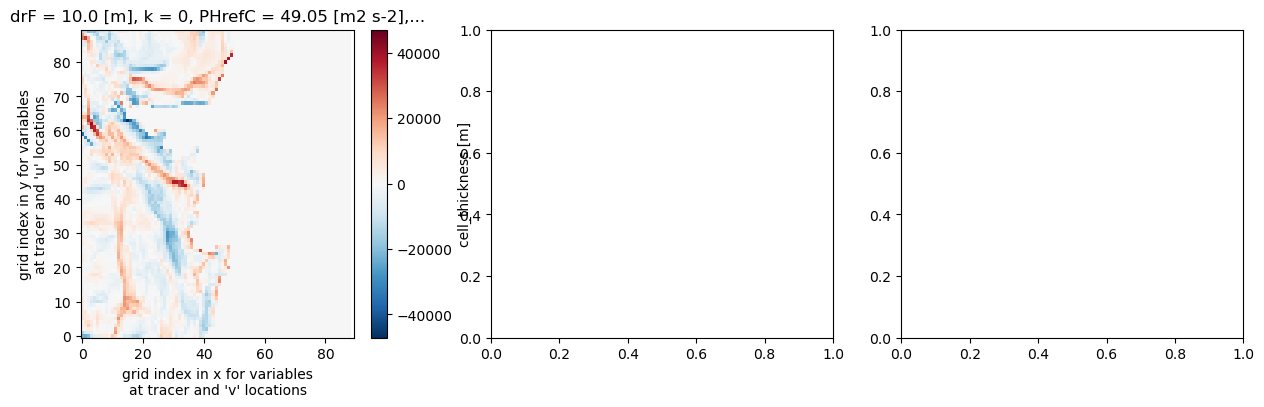

In [9]:
fig, ax = plt.subplots(1, 3, figsize = (15, 4))
UVRES_CONV.isel(k = 0, tile = 12).plot(ax = ax[0])
UVRES_CONV2.isel(k = 0, tile = 12).plot(ax = ax[1])
UVRES_CONV3.isel(k = 0, tile = 12).plot(ax = ax[2])

In [ ]:
UVRES_CONV.sum(["tile", "i", "j"]).plot(label = "og", linestyle = "--", lw = 3)
UVRES_CONV2.sum(["tile", "i", "j"]).plot(label = "diff", linestyle = "--", lw = 2)
UVRES_CONV3.sum(["tile", "i", "j"]).plot(label = "diff2d", linestyle = "--", lw = 1)
plt.legend()